# **Acne Segmentation — U-Net + EfficientNet**

## **Install Dependencies**

In [1]:
!pip install -q segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.5 MB/s eta 0:00:0000:01


## **Imports**

In [2]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

import segmentation_models_pytorch as smp

## **Configuration**

In [3]:
ROOT = "/kaggle/input/datasets/karmagames/acne04-v2/"

MASKS_DIR = os.path.join(ROOT, "gt_masks/gt_masks")

# For a baseline experiment, which involves only augmentations
IMAGES_DIR = os.path.join(ROOT, "img_data/img_data")

# For a ROI experiment, which involves extraction of facial ROI region
# IMAGES_DIR = os.path.join(ROOT, "clean_roi/clean_roi")

# For a CLAHE & ITA experiment, which involves CLAHE transform, conditioned on ITA
# IMAGES_DIR = os.path.join(ROOT, "images_acne_preprocess/images_acne_preprocess")


IMAGE_SIZE = 512
BATCH_SIZE = 2
NUM_EPOCHS = 40
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
RANDOM_STATE = 42
THRESHOLD = 0.5
CHECKPOINT_PATH = "best_unet_effnet_b3_acne.pth"

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

print("Device:", DEVICE)

Device: cuda


## **Augmentations & Dataset**

In [4]:
class RandomGamma:
    def __init__(self, gamma_range=(0.8, 1.25), p=0.5):
        self.gamma_range = gamma_range
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            gamma = random.uniform(*self.gamma_range)
            return TF.adjust_gamma(img, gamma)
        return img


class RandomGaussianBlur:
    def __init__(self, radius_range=(0.1, 0.8), p=0.2):
        self.radius_range = radius_range
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            sigma = random.uniform(*self.radius_range)
            return TF.gaussian_blur(img, kernel_size=3, sigma=sigma)
        return img


class AcneSegDataset(Dataset):
    def __init__(self, image_paths, masks_dir, image_size=512, train=True, return_path=False):
        self.image_paths = [Path(p) for p in image_paths]
        self.masks_dir = Path(masks_dir)
        self.image_size = image_size
        self.train = train
        self.return_path = return_path

        self.color_aug = transforms.Compose([
            transforms.ColorJitter(
                brightness=0.20,
                contrast=0.20,
                saturation=0.08,
                hue=0.015,
            ),
            RandomGamma(gamma_range=(0.80, 1.25), p=0.50),
            RandomGaussianBlur(radius_range=(0.1, 0.8), p=0.20),
        ])

        self.normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

    def __len__(self):
        return len(self.image_paths)

    def _get_mask_path(self, img_path):
        return self.masks_dir / f"{Path(img_path).stem}.png"

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self._get_mask_path(img_path)

        img = cv2.imread(str(img_path))
        if img is None:
            raise FileNotFoundError(f"Image not found: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"Mask not found: {mask_path}")

        img = cv2.resize(img, (self.image_size, self.image_size), interpolation=cv2.INTER_AREA)
        mask = cv2.resize(mask, (self.image_size, self.image_size), interpolation=cv2.INTER_NEAREST)

        img = TF.to_pil_image(img)
        mask = TF.to_pil_image(mask)

        if self.train:
            if random.random() < 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)

            if random.random() < 0.15:
                img = TF.vflip(img)
                mask = TF.vflip(mask)

            angle = random.uniform(-10, 10)
            img = TF.rotate(img, angle, interpolation=InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

            img = self.color_aug(img)

        img = TF.to_tensor(img)
        img = self.normalize(img)

        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()

        if self.return_path:
            return img, mask, str(img_path)

        return img, mask

## **Data Prepare**

In [5]:
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

all_image_paths = []
for fname in sorted(os.listdir(IMAGES_DIR)):
    if Path(fname).suffix.lower() not in VALID_EXTS:
        continue

    img_path = os.path.join(IMAGES_DIR, fname)
    mask_path = os.path.join(MASKS_DIR, Path(fname).stem + ".png")

    if os.path.exists(mask_path):
        all_image_paths.append(img_path)

print(f"Found {len(all_image_paths)} image-mask pairs")

train_paths, temp_paths = train_test_split(
    all_image_paths,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
)

val_paths, test_paths = train_test_split(
    temp_paths,
    test_size=0.5,
    random_state=RANDOM_STATE,
    shuffle=True,
)

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Found 1204 image-mask pairs
Train: 963
Val: 120
Test: 121


In [6]:
train_ds = AcneSegDataset(
    image_paths=train_paths,
    masks_dir=MASKS_DIR,
    image_size=IMAGE_SIZE,
    train=True,
)

val_ds = AcneSegDataset(
    image_paths=val_paths,
    masks_dir=MASKS_DIR,
    image_size=IMAGE_SIZE,
    train=False,
)

test_ds = AcneSegDataset(
    image_paths=test_paths,
    masks_dir=MASKS_DIR,
    image_size=IMAGE_SIZE,
    train=False,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

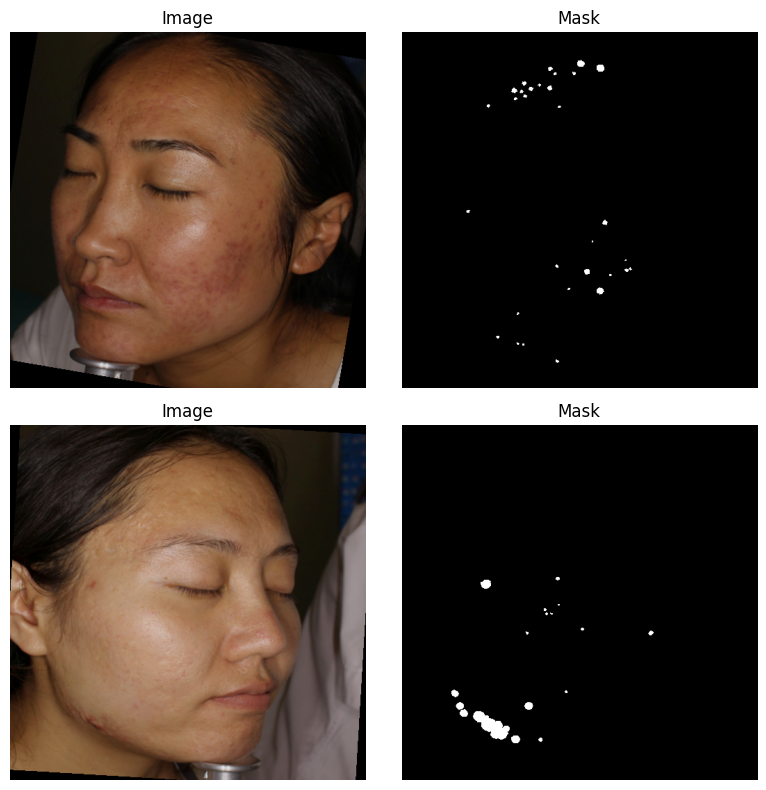

In [7]:
def denormalize_imagenet(img):
    mean = np.array(IMAGENET_MEAN)
    std = np.array(IMAGENET_STD)

    img = img.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * std + mean
    return np.clip(img, 0, 1)


def show_batch_with_masks(loader, n=4):
    imgs, masks = next(iter(loader))
    n = min(n, imgs.shape[0])

    fig, axes = plt.subplots(n, 2, figsize=(8, 4 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        axes[i, 0].imshow(denormalize_imagenet(imgs[i]))
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(masks[i, 0], cmap="gray")
        axes[i, 1].set_title("Mask")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()


show_batch_with_masks(train_loader)

## **Loss and Metrics**

In [8]:
bce_loss = nn.BCEWithLogitsLoss()


def dice_loss(logits, targets, smooth=1.0):
    probs = torch.sigmoid(logits)

    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (probs * targets).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (
        probs.sum(dim=1) + targets.sum(dim=1) + smooth
    )

    return 1.0 - dice.mean()


def bce_dice_loss(logits, targets):
    return bce_loss(logits, targets) + dice_loss(logits, targets)


def batch_iou_dice(logits, targets, threshold=0.5, eps=1e-8):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (preds.sum(dim=1) + targets.sum(dim=1) + eps)

    return iou.mean().item(), dice.mean().item()

## **Training Functions**

In [9]:
def train_one_epoch(model, loader, optimizer, device, epoch, total_epochs):
    model.train()

    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0

    pbar = tqdm(loader, desc=f"Epoch {epoch + 1}/{total_epochs}", leave=False)

    for imgs, masks in pbar:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = bce_dice_loss(logits, masks)

        loss.backward()
        optimizer.step()

        iou, dice = batch_iou_dice(logits.detach(), masks, threshold=THRESHOLD)

        running_loss += loss.item()
        running_iou += iou
        running_dice += dice

        pbar.set_postfix(loss=loss.item(), iou=iou, dice=dice)

    n = len(loader)
    return {
        "loss": running_loss / n,
        "iou": running_iou / n,
        "dice": running_dice / n,
    }


@torch.no_grad()
def evaluate(model, loader, device, threshold=0.5, eps=1e-8):
    model.eval()

    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0

    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    total_tn = 0.0

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        logits = model(imgs)
        loss = bce_dice_loss(logits, masks)

        iou, dice = batch_iou_dice(logits, masks, threshold=threshold)

        running_loss += loss.item()
        running_iou += iou
        running_dice += dice

        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

        total_tp += (preds * masks).sum().item()
        total_fp += (preds * (1 - masks)).sum().item()
        total_fn += ((1 - preds) * masks).sum().item()
        total_tn += ((1 - preds) * (1 - masks)).sum().item()

    n = len(loader)

    accuracy = (total_tp + total_tn) / (total_tp + total_tn + total_fp + total_fn + eps)
    precision = total_tp / (total_tp + total_fp + eps)
    recall = total_tp / (total_tp + total_fn + eps)

    return {
        "loss": running_loss / n,
        "iou": running_iou / n,
        "dice": running_dice / n,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
    }

## **Model**

In [10]:
model = smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
)

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

## **Training**

In [ ]:
best_val_dice = -1.0

history = {
    "train_loss": [],
    "train_iou": [],
    "train_dice": [],
    "val_loss": [],
    "val_iou": [],
    "val_dice": [],
}

for epoch in range(NUM_EPOCHS):
    train_metrics = train_one_epoch(model, train_loader, optimizer, DEVICE, epoch, NUM_EPOCHS)
    val_metrics = evaluate(model, val_loader, DEVICE, threshold=THRESHOLD)

    scheduler.step()

    history["train_loss"].append(train_metrics["loss"])
    history["train_iou"].append(train_metrics["iou"])
    history["train_dice"].append(train_metrics["dice"])

    history["val_loss"].append(val_metrics["loss"])
    history["val_iou"].append(val_metrics["iou"])
    history["val_dice"].append(val_metrics["dice"])

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"train_loss={train_metrics['loss']:.4f}, "
        f"train_iou={train_metrics['iou']:.4f}, "
        f"train_dice={train_metrics['dice']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f}, "
        f"val_iou={val_metrics['iou']:.4f}, "
        f"val_dice={val_metrics['dice']:.4f}, "
        f"val_precision={val_metrics['precision']:.4f}, "
        f"val_recall={val_metrics['recall']:.4f}"
    )

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"Saved best model to {CHECKPOINT_PATH}")

Epoch 1/40:   0%|          | 0/482 [00:00<?, ?it/s]

## **Training Curves**

In [ ]:
def plot_history(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title("Training Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_dice"], label="Train Dice")
    plt.plot(history["val_dice"], label="Validation Dice")
    plt.title("Dice Score")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_history(history)

## **Test Evaluation**

In [ ]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.to(DEVICE)

test_metrics = evaluate(model, test_loader, DEVICE, threshold=THRESHOLD)
print("Test metrics:")
for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

## **Predictions Visualization**

In [ ]:
@torch.no_grad()
def predict_batch(model, loader, device, threshold=0.5):
    model.eval()
    imgs, masks = next(iter(loader))

    imgs = imgs.to(device)
    masks = masks.to(device)

    logits = model(imgs)
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    return imgs.cpu(), masks.cpu(), logits.cpu(), preds.cpu(), probs.cpu()


def single_iou_dice(logit, target, threshold=0.5, eps=1e-8):
    if logit.ndim == 3:
        logit = logit.squeeze(0)
    if target.ndim == 3:
        target = target.squeeze(0)

    prob = torch.sigmoid(logit)
    pred = (prob > threshold).float()

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (pred.sum() + target.sum() + eps)

    return iou.item(), dice.item(), prob.cpu().numpy()


def make_error_overlay(img, pred, gt, alpha=0.45):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = pred & gt
    fp = pred & (~gt)
    fn = (~pred) & gt

    overlay = img.copy()
    overlay[tp] = (1 - alpha) * overlay[tp] + alpha * np.array([0.0, 1.0, 0.0])
    overlay[fp] = (1 - alpha) * overlay[fp] + alpha * np.array([1.0, 0.0, 0.0])
    overlay[fn] = (1 - alpha) * overlay[fn] + alpha * np.array([0.0, 0.0, 1.0])

    return np.clip(overlay, 0, 1)


def show_predictions_overlay(imgs, masks, logits, n=4, threshold=0.5, alpha=0.45):
    n = min(n, imgs.shape[0])
    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = denormalize_imagenet(imgs[i])
        gt = masks[i, 0].cpu().numpy()

        iou, dice, prob = single_iou_dice(logits[i], masks[i], threshold=threshold)
        pred = (prob > threshold).astype(np.float32)
        overlay = make_error_overlay(img, pred, gt, alpha=alpha)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt, cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred, cmap="gray")
        axes[i, 2].set_title(f"Prediction
Dice={dice:.3f} IoU={iou:.3f}")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title("Overlay
Green=TP Red=FP Blue=FN")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()


imgs, masks, logits, preds, probs = predict_batch(model, test_loader, DEVICE, threshold=THRESHOLD)
show_predictions_overlay(imgs, masks, logits, n=4, threshold=THRESHOLD)